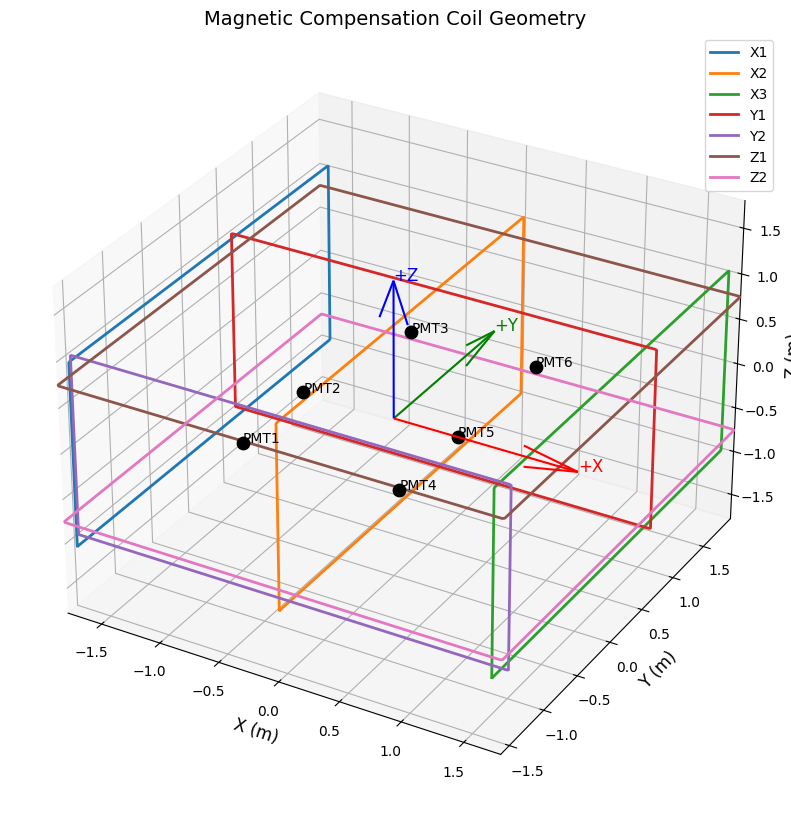

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sys
import os

# ============================================================
# Add src folder to path
# ============================================================

src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.append(src_path)

# ============================================================
# Imports
# ============================================================

from coils import coils
from pmts import PMTs

# ============================================================
# Create figure
# ============================================================

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(111, projection='3d')

# ============================================================
# Plot coils
# ============================================================

for coil_name, (segment_centers, dl_vectors) in coils.items():

    x = segment_centers[:,0]
    y = segment_centers[:,1]
    z = segment_centers[:,2]

    ax.plot(
        x,
        y,
        z,
        linewidth=2,
        label=coil_name
    )

# ============================================================
# Plot PMTs
# ============================================================

for pmt_name, position in PMTs.items():

    x, y, z = position

    ax.scatter(
        x,
        y,
        z,
        s=80,
        color='black'
    )

    ax.text(
        x,
        y,
        z,
        pmt_name,
        fontsize=10
    )

# ============================================================
# Coordinate axes
# ============================================================

axis_length = 1.5

ax.quiver(0,0,0, axis_length,0,0, color='r')
ax.quiver(0,0,0, 0,axis_length,0, color='g')
ax.quiver(0,0,0, 0,0,axis_length, color='b')

ax.text(axis_length,0,0,'+X', color='r', fontsize=12)
ax.text(0,axis_length,0,'+Y', color='g', fontsize=12)
ax.text(0,0,axis_length,'+Z', color='b', fontsize=12)

# ============================================================
# Equal aspect ratio
# ============================================================

all_points = []

# Coil points
for segment_centers, _ in coils.values():
    all_points.append(segment_centers)

# PMT points
for position in PMTs.values():
    all_points.append(position.reshape(1,3))

all_points = np.vstack(all_points)

x_limits = [all_points[:,0].min(), all_points[:,0].max()]
y_limits = [all_points[:,1].min(), all_points[:,1].max()]
z_limits = [all_points[:,2].min(), all_points[:,2].max()]

x_range = x_limits[1] - x_limits[0]
y_range = y_limits[1] - y_limits[0]
z_range = z_limits[1] - z_limits[0]

max_range = max(x_range, y_range, z_range)

x_mid = np.mean(x_limits)
y_mid = np.mean(y_limits)
z_mid = np.mean(z_limits)

ax.set_xlim(x_mid - max_range/2, x_mid + max_range/2)
ax.set_ylim(y_mid - max_range/2, y_mid + max_range/2)
ax.set_zlim(z_mid - max_range/2, z_mid + max_range/2)

# ============================================================
# Labels
# ============================================================

ax.set_xlabel("X (m)", fontsize=12)
ax.set_ylabel("Y (m)", fontsize=12)
ax.set_zlabel("Z (m)", fontsize=12)

ax.set_title("Magnetic Compensation Coil Geometry", fontsize=14)

ax.legend()

plt.show()

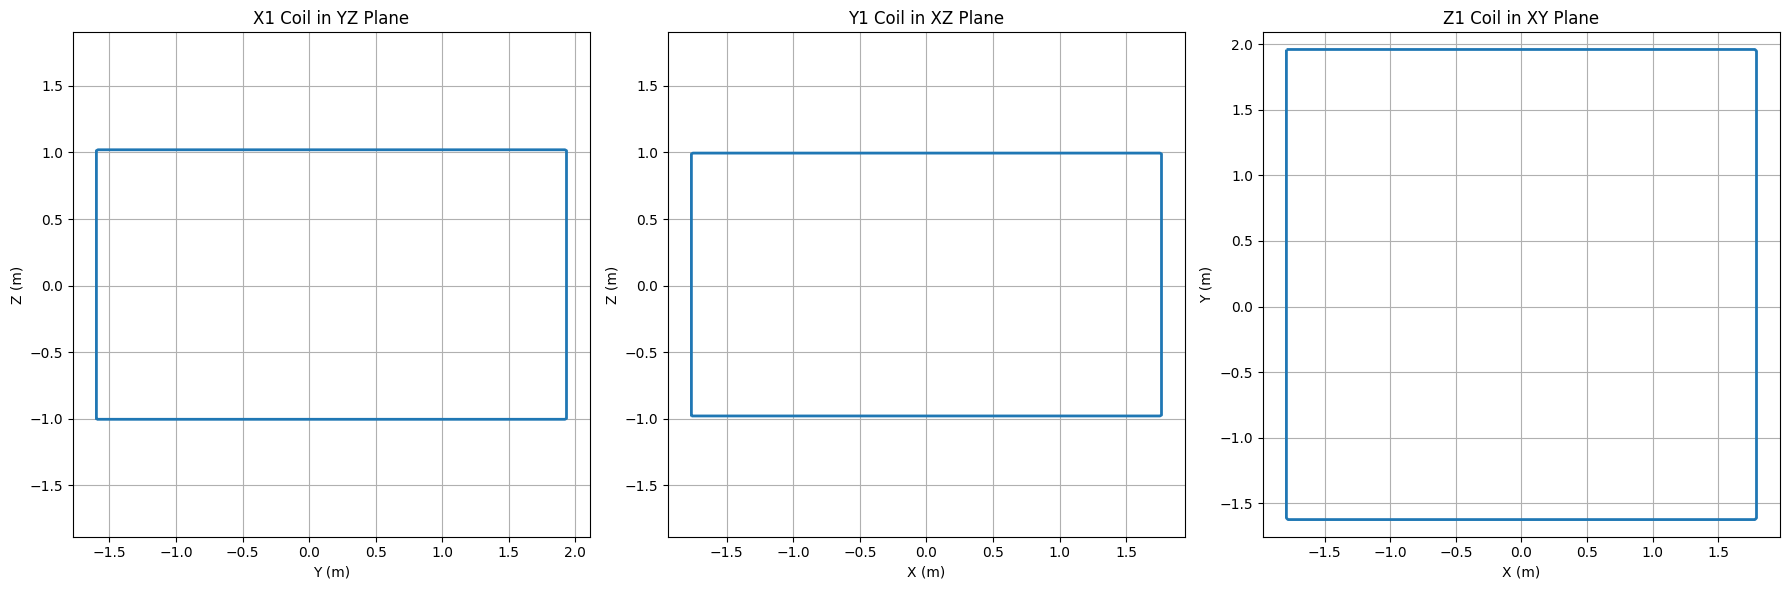

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

# ============================================================
# Add src folder to path
# ============================================================

src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.append(src_path)

# ============================================================
# Imports
# ============================================================

from coils import coils

# ============================================================
# Create subplots
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(18,6))

# ============================================================
# X coil -> yz plane
# ============================================================

segment_centers, _ = coils['X1']

y = segment_centers[:,1]
z = segment_centers[:,2]

axs[0].plot(y, z, linewidth=2)

axs[0].set_title("X1 Coil in YZ Plane")

axs[0].set_xlabel("Y (m)")
axs[0].set_ylabel("Z (m)")

axs[0].grid(True)
axs[0].axis('equal')

# ============================================================
# Y coil -> xz plane
# ============================================================

segment_centers, _ = coils['Y1']

x = segment_centers[:,0]
z = segment_centers[:,2]

axs[1].plot(x, z, linewidth=2)

axs[1].set_title("Y1 Coil in XZ Plane")

axs[1].set_xlabel("X (m)")
axs[1].set_ylabel("Z (m)")

axs[1].grid(True)
axs[1].axis('equal')

# ============================================================
# Z coil -> xy plane
# ============================================================

segment_centers, _ = coils['Z1']

x = segment_centers[:,0]
y = segment_centers[:,1]

axs[2].plot(x, y, linewidth=2)

axs[2].set_title("Z1 Coil in XY Plane")

axs[2].set_xlabel("X (m)")
axs[2].set_ylabel("Y (m)")

axs[2].grid(True)
axs[2].axis('equal')

# ============================================================
# Final display
# ============================================================

plt.tight_layout()

plt.show()

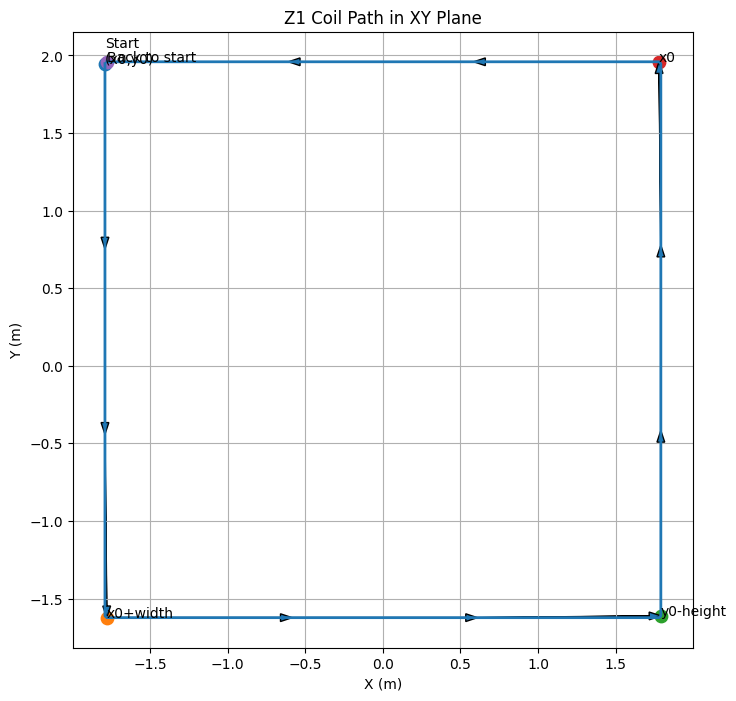

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

# ============================================================
# Add src folder to path
# ============================================================

src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.append(src_path)

# ============================================================
# Imports
# ============================================================

from coils import coils

# ============================================================
# Get Z1 coil data
# ============================================================

segment_centers, _ = coils['Z1']

x = segment_centers[:,0]
y = segment_centers[:,1]

# ============================================================
# Plot setup
# ============================================================

fig, ax = plt.subplots(figsize=(8,8))

ax.plot(x, y, linewidth=2)

# ============================================================
# Mark important corner transitions
# ============================================================

N = len(x)

# Since:
# 4 sides
# equal segmentation

side_pts = N // 4

corner_indices = [
    0,
    side_pts,
    2*side_pts,
    3*side_pts,
    N-1
]

corner_labels = [
    "Start\n(x0,y0)",
    "x0+width",
    "y0-height",
    "x0",
    "Back to start"
]

# ============================================================
# Plot corners and labels
# ============================================================

for idx, label in zip(corner_indices, corner_labels):

    ax.scatter(
        x[idx],
        y[idx],
        s=80
    )

    ax.text(
        x[idx],
        y[idx],
        label,
        fontsize=10
    )

# ============================================================
# Draw arrows showing traversal direction
# ============================================================

step = side_pts // 3

for i in range(0, N-step, step):

    dx = x[i+step] - x[i]
    dy = y[i+step] - y[i]

    ax.arrow(
        x[i],
        y[i],
        dx,
        dy,
        head_width=0.05,
        length_includes_head=True
    )

# ============================================================
# Labels
# ============================================================

ax.set_title("Z1 Coil Path in XY Plane")

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")

ax.grid(True)

ax.axis('equal')

plt.show()

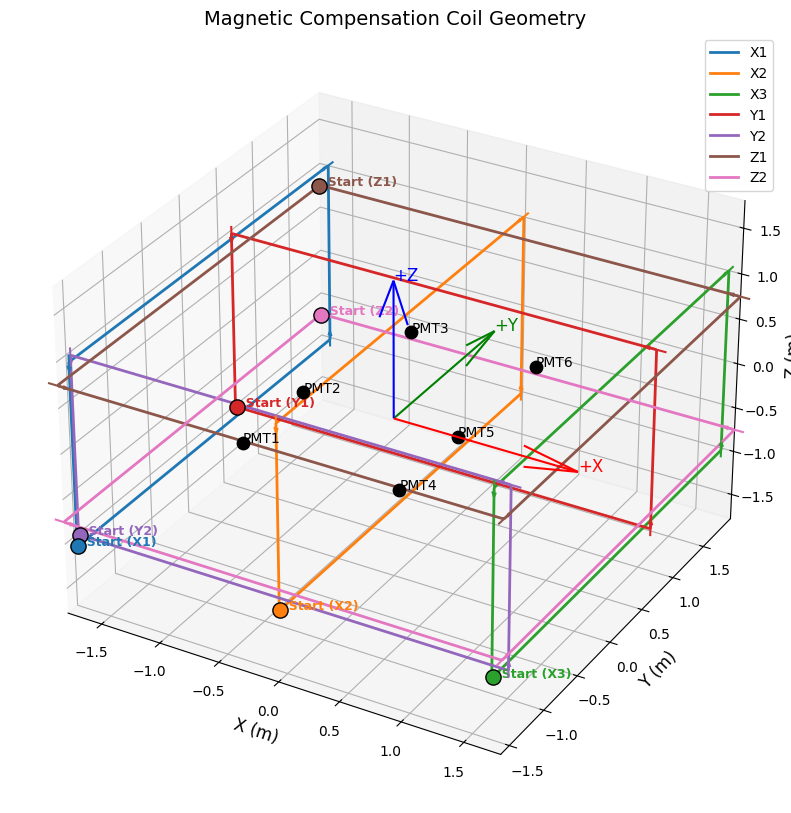

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sys
import os

# ============================================================
# Add src folder to path
# ============================================================

src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.append(src_path)

# ============================================================
# Imports
# ============================================================

from coils import coils
from pmts import PMTs

# ============================================================
# Create figure
# ============================================================

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(111, projection='3d')

# ============================================================
# Plot coils (with starting points and direction arrows)
# ============================================================

for coil_name, (segment_centers, dl_vectors) in coils.items():

    x = segment_centers[:,0]
    y = segment_centers[:,1]
    z = segment_centers[:,2]

    # 1. Plot the main coil line
    line = ax.plot(
        x, y, z,
        linewidth=2,
        label=coil_name
    )
    coil_color = line[0].get_color() # Match arrows to line color

    # 2. Mark the starting point
    ax.scatter(
        x[0], y[0], z[0],
        color=coil_color,
        marker='o',
        s=120,
        edgecolors='black',
        zorder=5
    )
    ax.text(
        x[0], y[0], z[0], 
        f"  Start ({coil_name})", 
        color=coil_color, 
        fontsize=9, 
        fontweight='bold'
    )

    # 3. Add directional arrows (quivers) along the loop
    # We sample a few points (e.g., at 25%, 50%, 75% of the array) so it's not cluttered
    num_segments = len(segment_centers)
    arrow_indices = [int(num_segments * 0.25), int(num_segments * 0.50), int(num_segments * 0.75)]

    for idx in arrow_indices:
        # Get position and its corresponding direction vector (dl)
        px, py, pz = segment_centers[idx]
        dl_x, dl_y, dl_z = dl_vectors[idx]

        # Normalize dl_vector so all arrows are the same visual size
        dl_len = np.sqrt(dl_x**2 + dl_y**2 + dl_z**2)
        if dl_len > 0:
            arrow_scale = max_range * 0.05  # Scale arrow to 5% of plot size
            ux = (dl_x / dl_len) * arrow_scale
            uy = (dl_y / dl_len) * arrow_scale
            uz = (dl_z / dl_len) * arrow_scale

            ax.quiver(
                px, py, pz, 
                ux, uy, uz, 
                color=coil_color,
                length=1.0, 
                pivot='middle',
                arrow_length_ratio=0.3
            )


# ============================================================
# Plot PMTs
# ============================================================

for pmt_name, position in PMTs.items():

    x, y, z = position

    ax.scatter(
        x,
        y,
        z,
        s=80,
        color='black'
    )

    ax.text(
        x,
        y,
        z,
        pmt_name,
        fontsize=10
    )

# ============================================================
# Coordinate axes
# ============================================================

axis_length = 1.5

ax.quiver(0,0,0, axis_length,0,0, color='r')
ax.quiver(0,0,0, 0,axis_length,0, color='g')
ax.quiver(0,0,0, 0,0,axis_length, color='b')

ax.text(axis_length,0,0,'+X', color='r', fontsize=12)
ax.text(0,axis_length,0,'+Y', color='g', fontsize=12)
ax.text(0,0,axis_length,'+Z', color='b', fontsize=12)

# ============================================================
# Equal aspect ratio
# ============================================================

all_points = []

# Coil points
for segment_centers, _ in coils.values():
    all_points.append(segment_centers)

# PMT points
for position in PMTs.values():
    all_points.append(position.reshape(1,3))

all_points = np.vstack(all_points)

x_limits = [all_points[:,0].min(), all_points[:,0].max()]
y_limits = [all_points[:,1].min(), all_points[:,1].max()]
z_limits = [all_points[:,2].min(), all_points[:,2].max()]

x_range = x_limits[1] - x_limits[0]
y_range = y_limits[1] - y_limits[0]
z_range = z_limits[1] - z_limits[0]

max_range = max(x_range, y_range, z_range)

x_mid = np.mean(x_limits)
y_mid = np.mean(y_limits)
z_mid = np.mean(z_limits)

ax.set_xlim(x_mid - max_range/2, x_mid + max_range/2)
ax.set_ylim(y_mid - max_range/2, y_mid + max_range/2)
ax.set_zlim(z_mid - max_range/2, z_mid + max_range/2)

# ============================================================
# Labels
# ============================================================

ax.set_xlabel("X (m)", fontsize=12)
ax.set_ylabel("Y (m)", fontsize=12)
ax.set_zlabel("Z (m)", fontsize=12)

ax.set_title("Magnetic Compensation Coil Geometry", fontsize=14)

ax.legend()

plt.show()